In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import matplotlib.pyplot as plt


In [2]:
dataset =tf.keras.preprocessing.image_dataset_from_directory(
    "../dataset/PlantVillage",
    shuffle=True,
    image_size=(256, 256),
    batch_size=32,
)

Found 2152 files belonging to 3 classes.


In [3]:
class_names = dataset.class_names
len(dataset)

68

(32, 256, 256, 3)
(32,)


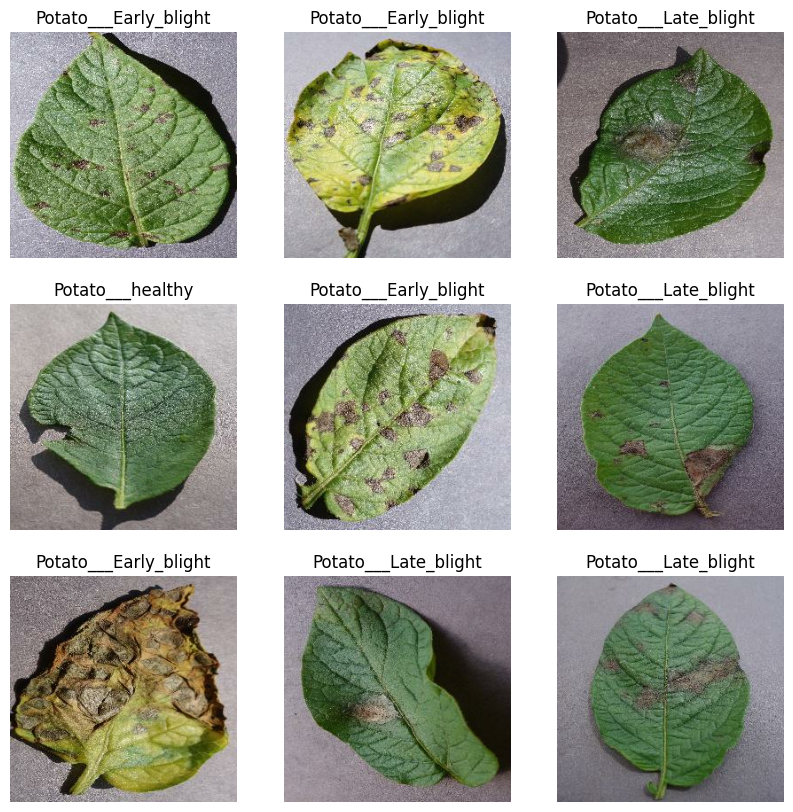

In [4]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.shape)
plt.figure(figsize=(10, 10))
for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [5]:
length = len(dataset)
print(length)
train_ds = dataset.take(int(length * 0.8))
val_ds = dataset.skip(int(length * 0.8)).take(int(length * 0.1))
test_ds = dataset.skip(int(length * 0.9)).take(int(length * 0.1))
print(len(train_ds))
print(len(val_ds))  
print(len(test_ds))

68
54
6
6


In [6]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size)

    return train_ds, val_ds, test_ds

In [7]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)
print(f"Training set size: {len(train_ds)}")
print(f"Validation set size: {len(val_ds)}")
print(f"Testing set size: {len(test_ds)}")

Training set size: 54
Validation set size: 6
Testing set size: 8


In [8]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

# Augmentation

In [9]:
resize_and_rescale =tf.keras.Sequential([
    layers.Resizing(256, 256),
    layers.Rescaling(1 / 255.0)
])

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(0.2),

])

# Build CNN Model


In [11]:
input_shape = (256, 256, 3)
n_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=input_shape),

    # Resize & Rescale
    layers.Resizing(256, 256),
    layers.Rescaling(1 / 255.0),

    # Augmentation
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(0.2),

    # CNN blocks
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(n_classes, activation="softmax"),
])
model.build(input_shape=(None, 256, 256, 3))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_1             │ (None, 256, 256, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 256, 256, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 757,443 (2.89 MB)

 Trainable params: 757,443 (2.89 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer=optimizers.Adam(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],    
)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor="loss",  # metric to watch
    patience=8,          # stop after 5 epochs of no improvement
    restore_best_weights=True  # revert to best epoch's weights
)


In [14]:
# verbose=1 for progress bar, verbose=2 for one line per epoch, verbose=0 for silent
# early stopping will prevent overfitting by halting training when the validation loss stops improving
history = model.fit(train_ds, validation_data=val_ds, epochs=50, batch_size=32, verbose=1)


Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 862ms/step - accuracy: 0.4554 - loss: 1.0213 - val_accuracy: 0.4583 - val_loss: 0.9453
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 782ms/step - accuracy: 0.4695 - loss: 0.9213 - val_accuracy: 0.5179 - val_loss: 0.8705
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 725ms/step - accuracy: 0.4595 - loss: 0.9093 - val_accuracy: 0.4219 - val_loss: 0.8695
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 698ms/step - accuracy: 0.4718 - loss: 0.9185 - val_accuracy: 0.4740 - val_loss: 0.9065
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 841ms/step - accuracy: 0.4554 - loss: 0.9153 - val_accuracy: 0.4271 - val_loss: 0.8786
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 45s 818ms/step - accuracy: 0.4583 - loss: 0.9120 - val_accuracy: 0.5156 - val_loss: 0.8649
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 861ms/step - accuracy: 0.4343 - loss: 0.8977 - val_accuracy: 0.4062 - val_loss: 0.9118
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 45s 814ms/step - accuracy: 0.4806 - loss: 0.9006 - val_accu

In [16]:
scores = model.evaluate(test_ds)
print(f"Test Loss: {scores[0]:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.5039 - loss: 0.9059
Test Loss: 0.9059


In [17]:
for image_batch , label_batch in test_ds.take(1):
    first_image = images[0].numpy().astype("uint8")
    first_label = labels[0].numpy()
    print(f"First image shape: {first_image.shape}")
    print(f"First label: {class_names[first_label]}")

    batch_predictions = model.predict(image_batch)
    print(np.argmax(batch_predictions[0]), class_names[np.argmax(batch_predictions[0])])

First image shape: (256, 256, 3)
First label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 893ms/step
1 Potato___Late_blight


In [18]:
def predict(model,img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create a batch

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])
    
    return predicted_class, confidence

In [20]:
model.save("potato_disease_model.keras")